# 全域網格連接性 (Global Connectivity) 演示與驗證

本筆記本旨在展示如何利用「頂點配對哈希法 (Vertex Pairing Hash)」在非結構網格上建立相鄰元素的連接關係，包含元素對元素 ($EToE$) 與元素對面 ($EToF$) 的拓撲映射。

我們將透過 Pandas DataFrame 將連接矩陣視覺化，並執行嚴格的幾何中心對齊檢查與網格雷達圖繪製，確保拓撲結構與實體幾何完全吻合。

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from pathlib import Path

# 專案路徑設定 (確保可匯入 src 模組)
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 匯入我們建構好的核心模組
try:
    from src.bases.simplex_2d import generate_subdivided_triangle
    from src.core.connectivity import build_connectivity
    from src.core.validation import check_geometric_centroids, plot_connectivity_map
except ImportError:
    print("⚠️ 警告：找不到 src 模組，請確保當前環境路徑正確。")

## 1. 產生測試網格 (Generate Test Mesh)

我們使用標準的參考三角形剖分函數來建立一個逆時針排列 (CCW) 的均勻網格。這裡以 $N_{div} = 4$ 為例，這會產生 16 個小三角形元素。

In [2]:
# 產生剖分層級 4 的測試網格
N_DIV = 4
nodes, EToV = generate_subdivided_triangle(N_DIV)
EToV = np.array(EToV)  # Convert to numpy array if needed

print(f"網格生成完畢！")
print(f"-> 總節點數 (N_vertices): {nodes.shape[0]}")
print(f"-> 總元素數 (N_elements): {EToV.shape[0]}")

網格生成完畢！
-> 總節點數 (N_vertices): 15
-> 總元素數 (N_elements): 16


## 2. 建立與檢查連接矩陣 (Build & Inspect Connectivity)

接下來呼叫 `build_connectivity` 透過哈希表計算相鄰關係。為了方便查閱，我們將 $EToE$ 轉譯為 Pandas DataFrame。其中 **黃色高亮** 的欄位代表該元素的面屬於「物理邊界」，因為它映射回自己。

In [3]:
# 計算連接矩陣
EToE, EToF = build_connectivity(EToV)

def highlight_boundaries_EToE(row):
    """若 EToE 映射回自己的元素編號，則為物理邊界，以黃色標示。"""
    return ['background-color: yellow' if val == row.name else 'color: lightgray' for val in row]

def highlight_boundaries_EToF(df_EToE, df_EToF):
    """利用 EToE 的資訊來高亮 EToF 的邊界。"""
    styles = pd.DataFrame('', index=df_EToF.index, columns=df_EToF.columns)
    for idx in df_EToF.index:
        for col in df_EToF.columns:
            if df_EToE.loc[idx, col] == idx:
                styles.loc[idx, col] = 'background-color: yellow'
            else:
                styles.loc[idx, col] = 'color: lightgray'
    return styles

# 顯示 EToE DataFrame
df_EToE = pd.DataFrame(EToE, columns=["Face 0", "Face 1", "Face 2"])
df_EToE.index.name = "Element (k)"
print("=== Element-to-Element (EToE) Connectivity ===")
display(df_EToE.style.apply(highlight_boundaries_EToE, axis=1))

# 顯示 EToF DataFrame
df_EToF = pd.DataFrame(EToF, columns=["Face 0", "Face 1", "Face 2"])
df_EToF.index.name = "Element (k)"
print("\n=== Element-to-Face (EToF) Connectivity ===")
display(df_EToF.style.apply(lambda x: highlight_boundaries_EToF(df_EToE, df_EToF), axis=None))

=== Element-to-Element (EToE) Connectivity ===


,Face 0,Face 1,Face 2
Element (k),,,
0,0,1,0
1,2,7,0
2,2,3,1
3,4,9,2
4,4,5,3
5,6,11,4
6,6,6,5
7,1,8,7
8,9,12,7



=== Element-to-Face (EToF) Connectivity ===


,Face 0,Face 1,Face 2
Element (k),,,
0,0,2,2
1,2,0,1
2,0,2,0
3,2,0,1
4,0,2,0
5,2,0,1
6,0,1,0
7,1,2,2
8,2,0,1


## 3. 幾何對齊驗證與雷達圖 (Geometric Validation & Visualization)

最後，我們透過物理空間的座標計算，執行雙向重心驗證 (`check_geometric_centroids`)，確保每一組內部邊界的兩側完美對齊。同時呼叫 `plot_connectivity_map` 視覺化網格連通性。

執行幾何驗證 (Geometric Centroid Sanity Check)...
GEOMETRIC CENTROID VALIDATION

✓ Geometric validation PASSED
  Internal faces checked: 36
  All face midpoints match (within tolerance: 1.00e-10)


繪製連接關係雷達圖...
Generating connectivity map visualization...

Drawing mesh edges...
  30 unique edges drawn
Computing element centroids...
  16 element centroids plotted
Drawing element connectivity arrows...
  18 element connections drawn
Plotting vertex nodes...
  15 vertices plotted



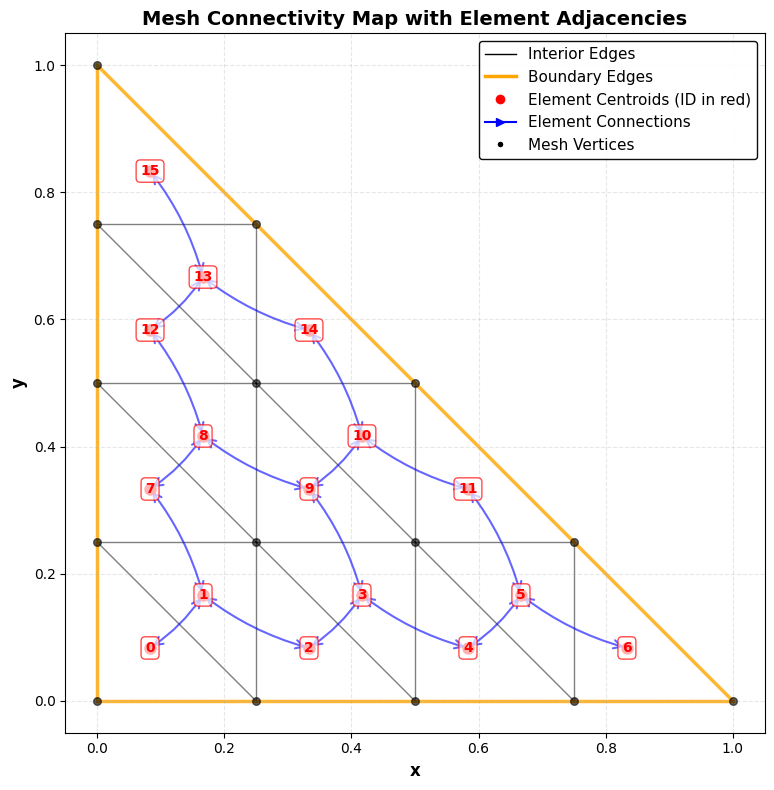

In [4]:
# 1. 幾何重心對齊檢查
print("=" * 80)
print("執行幾何驗證 (Geometric Centroid Sanity Check)...")
try:
    check_geometric_centroids(nodes, EToV, EToE, EToF)
except AssertionError as e:
    print(f"✗ 驗證失敗: {e}")
print("=" * 80)

# 2. 視覺化網格連通性
print("\n繪製連接關係雷達圖...")
fig, ax = plot_connectivity_map(nodes, EToV, EToE, figsize=(10, 8))
plt.show()